In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_to_data = '../data/spotify_data/'

import os
for dirname, _, filenames in os.walk(path_to_data):
    for filename in filenames:
        print(os.path.join(dirname, filename))

../data/spotify_data/dataset.csv


In [122]:
df = pd.read_csv(path_to_data + 'dataset.csv')

In [35]:
display(df.head())
display(df.info())

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

None

Выбросить : track_id, artists, album_name, track_name \
Попробую сначала обучить данные без признака track_genre, ибо они категориальные с кучей уникальных значений. К тому же мне почему-то кажется, что схожесть по жанрам можно определять пользуясь лишь аудио характеристиками, без связи слов

In [123]:
df = df.drop(columns=['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre'])

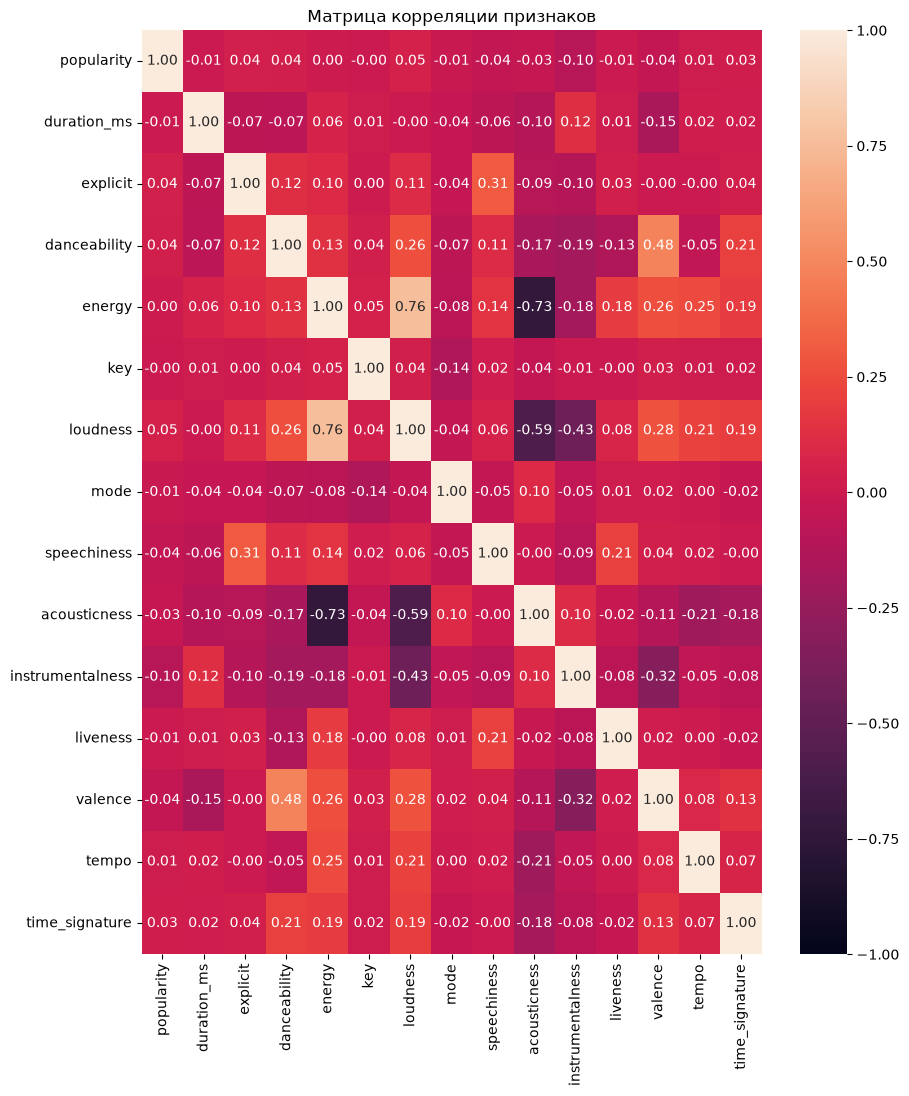

In [113]:
# Матрица корреляций 
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

In [114]:
display(df.nunique())
display(df.info())

popularity            101
duration_ms         50697
explicit                2
danceability         1174
energy               2083
key                    12
loudness            19480
mode                    2
speechiness          1489
acousticness         5061
instrumentalness     5346
liveness             1722
valence              1790
tempo               45653
time_signature          5
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   popularity        114000 non-null  int64  
 1   duration_ms       114000 non-null  int64  
 2   explicit          114000 non-null  bool   
 3   danceability      114000 non-null  float64
 4   energy            114000 non-null  float64
 5   key               114000 non-null  int64  
 6   loudness          114000 non-null  float64
 7   mode              114000 non-null  int64  
 8   speechiness       114000 non-null  float64
 9   acousticness      114000 non-null  float64
 10  instrumentalness  114000 non-null  float64
 11  liveness          114000 non-null  float64
 12  valence           114000 non-null  float64
 13  tempo             114000 non-null  float64
 14  time_signature    114000 non-null  int64  
dtypes: bool(1), float64(9), int64(5)
memory usage: 12.3 MB


None

Категориальные признаки : explicit, key, mode, time_signature \
Из них закодирую лишь key, причем растояние между 1 и 2 в key должно быть таким же как и между 0 и 11, поэтому необходимо цикличное кодирование, \
например синусно-косинусное преобразование.

In [115]:
from sklearn.preprocessing import FunctionTransformer

In [124]:
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(2 * np.pi * x / period))


def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(2 * np.pi * x / period))

key_sin = sin_transformer(12).fit_transform(df['key'])
key_cos = cos_transformer(12).fit_transform(df['key'])

df['key_sin'] = key_sin
df['key_cos'] = key_cos
df = df.drop(columns=['key'])

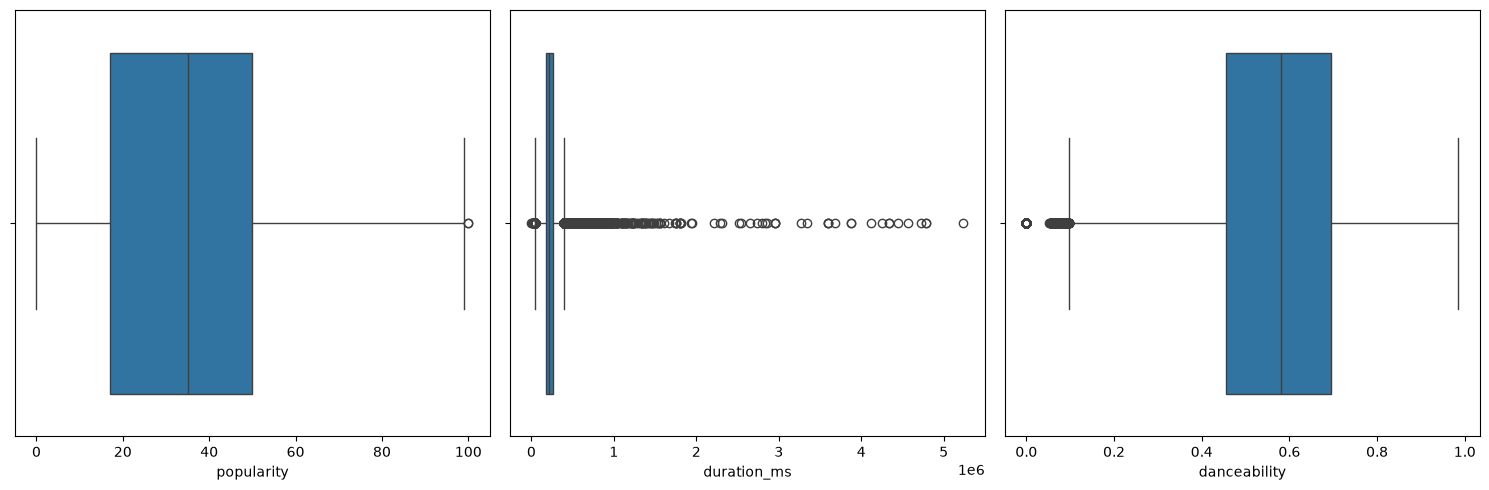

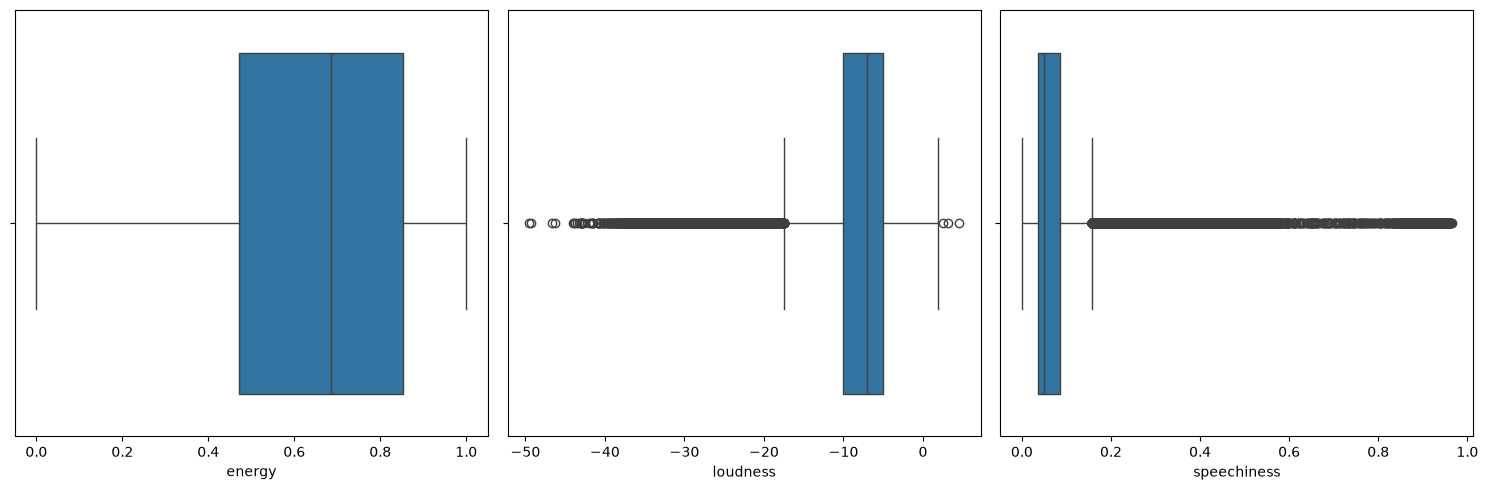

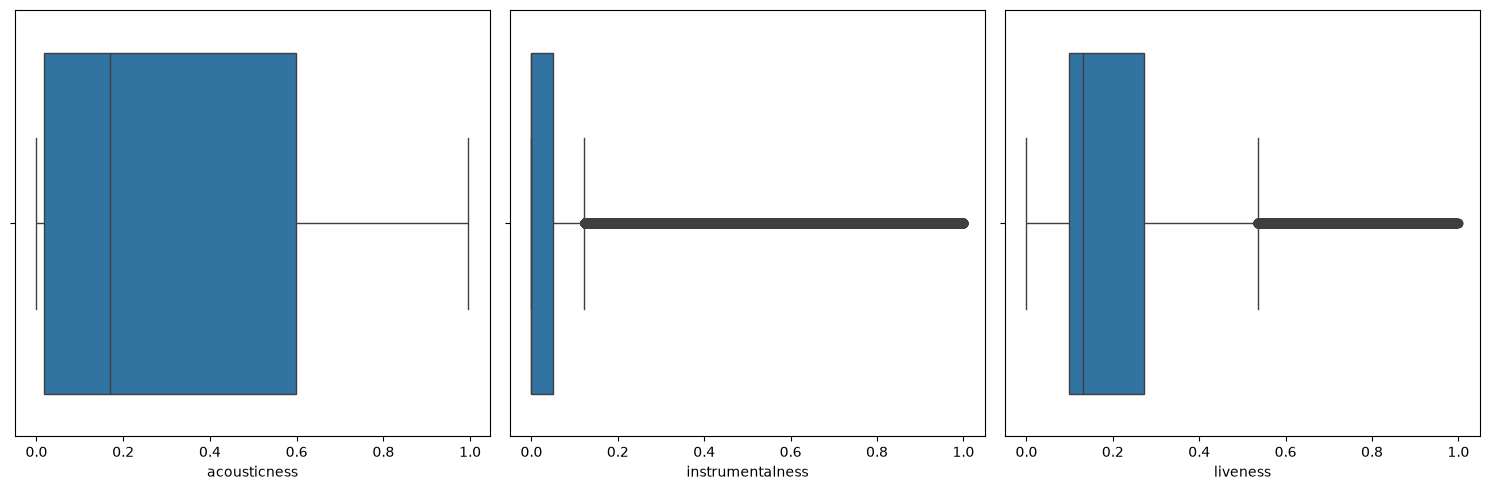

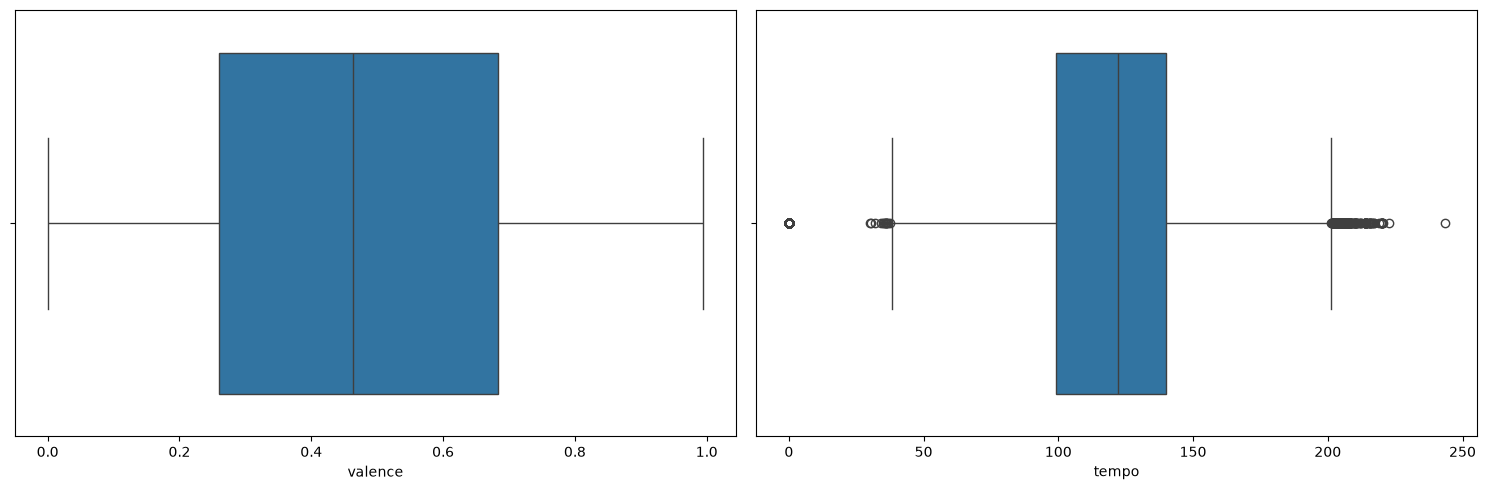

In [128]:
excl = ['explicit', 'key_cos', 'key_sin', 'mode', 'time_signature']
numeric_columns = [k for k in df.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5))
    for j in range(tmp):
        sns.boxplot(data=df, x=df[numeric_columns[i + j]], ax=axes[j])
    i = i + tmp

    plt.tight_layout()
    plt.show()


Также выброшу данные, у которых duration_ms > 1000 * 60 * 10 (10 минут) или duration_ms < 1000 * 30 (30 секунд), потому что вряд-ли это будут песни

Удалю то, что по громкости ниже -25 дб, ибо это скорее всего аудиокниги либо какие-то звуки природы. И удалю записи с околонулевым темпом

In [130]:
df = df[(1000 * 30 < df['duration_ms']) & (df['duration_ms'] < 1000 * 60 * 10) ]
df = df[df['loudness'] >= -25]
df = df[df['tempo'] >= 1]

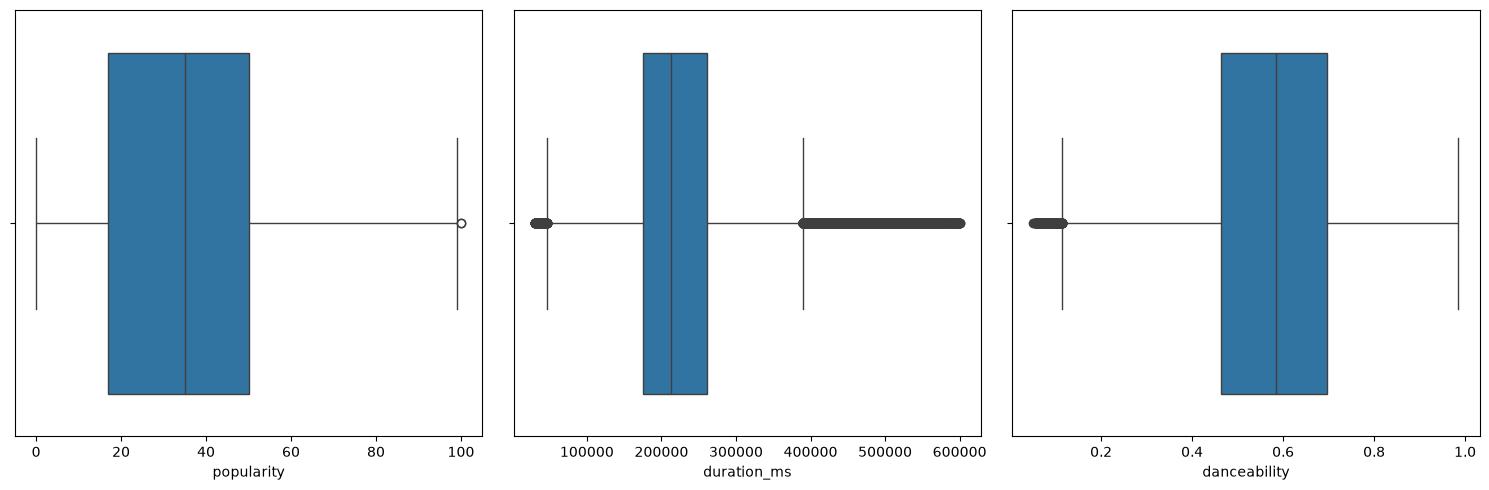

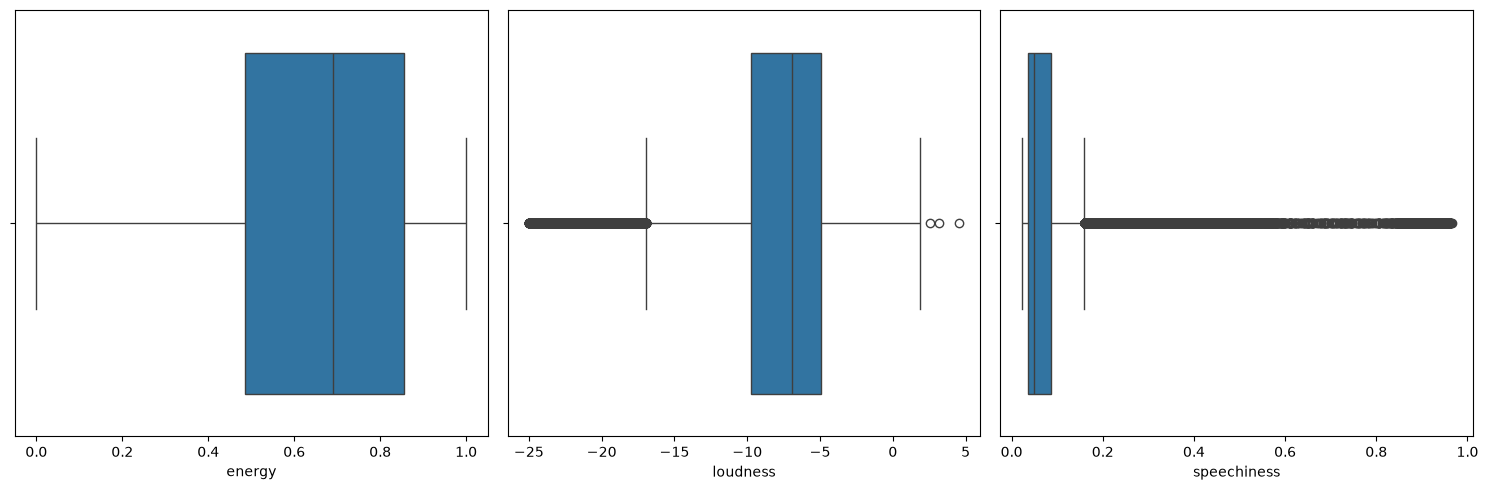

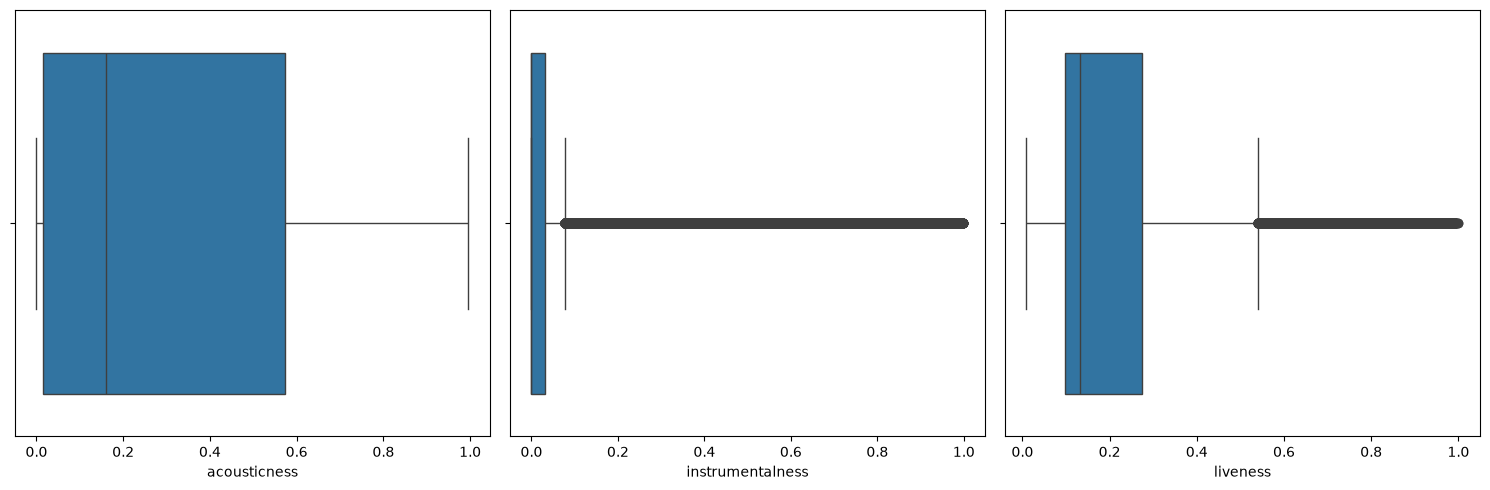

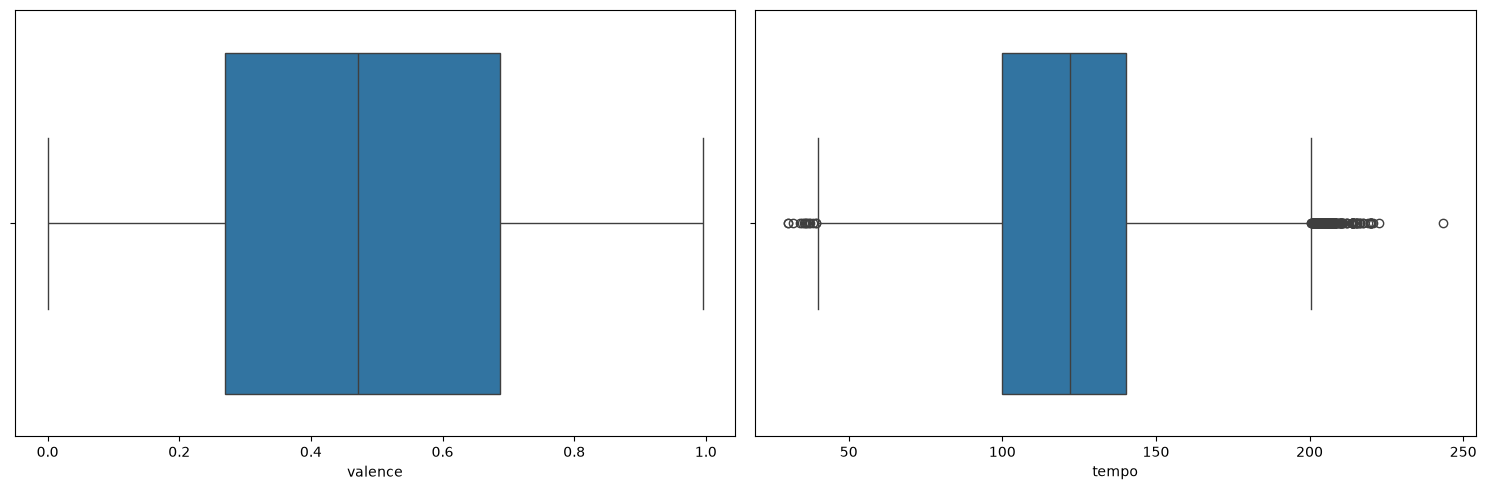

In [132]:
excl = ['explicit', 'key_cos', 'key_sin', 'mode', 'time_signature']
numeric_columns = [k for k in df.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5))
    for j in range(tmp):
        sns.boxplot(data=df, x=df[numeric_columns[i + j]], ax=axes[j])
    i = i + tmp

    plt.tight_layout()
    plt.show()


Преобразования: \
    **popularity** : std (нет выбросов, почти симметрия) \
    **duration_ms** :  robust (есть выбросы, почти симметрия)\
    **danceability** : robust (есть выбросы, есть симметрия)\
    **energy** : std (нет выбросов, почти симметрия)\
    **loudness** : robust (есть выбросы, почти симметрия)\
    **speechiness** : QuantileTransform (длинный хвост выбросов, сильная ассиметрия)\
    **acousticness** : QuantileTransform (выбросов нет, ассиметрия)\
    **instrumentalness** : QuantileTransform (длинный хвост выбросов, сильная ассиметрия)\
    **liveness** : QuantileTransform (длинный хвост выбросов, ассиметрия)\
    **valence** : std (нет выбросов, симметрия)\
    **tempo** : robust (есть выбросы, симметрия)



track_genre попробую закодировать через средние значения акустических характеристик либо через эмбединг слов

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler

In [101]:
ct = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), ['popularity', 'energy', 'valence']),      
        ('quantile', QuantileTransformer(output_distribution='normal', random_state=42), ['speechiness', 'acousticness', 'instrumentalness', 'liveness']),    
        ('robust', RobustScaler(), ['duration_ms', 'danceability', 'loudness', 'tempo'])     
    ],
    remainder='passthrough'
)

In [102]:
tranf_arr = ct.fit_transform(df)

In [ ]:
tranf_arr

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('std', ...), ('quantile', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

In [103]:
feature_names = ct.get_feature_names_out()
df_transformed = pd.DataFrame(tranf_arr, columns=feature_names)

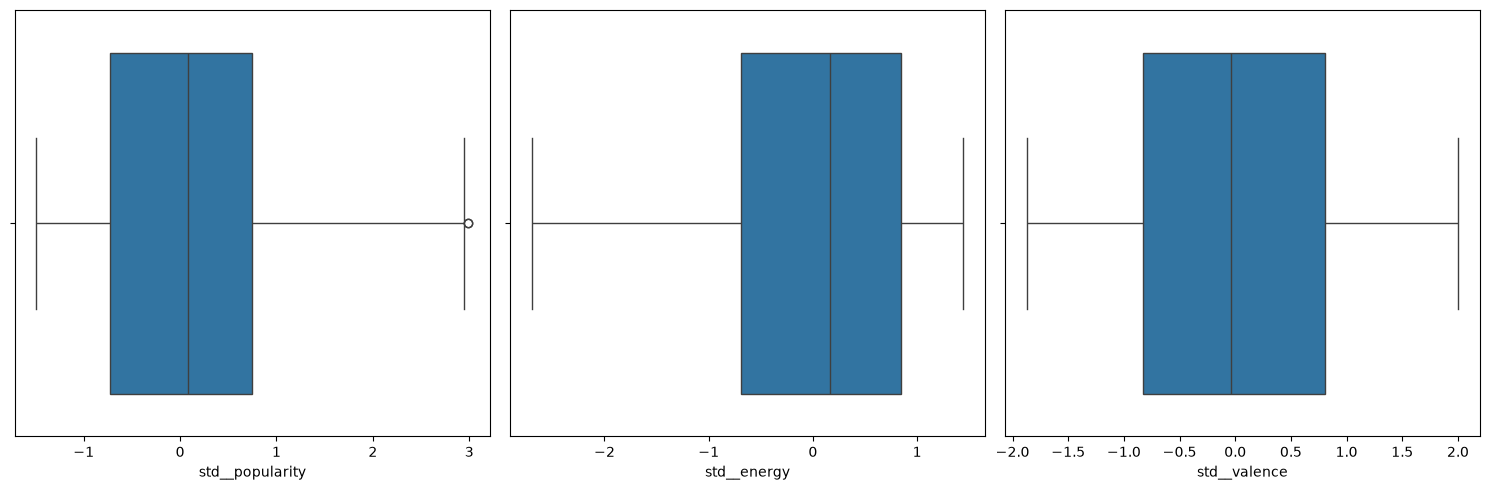

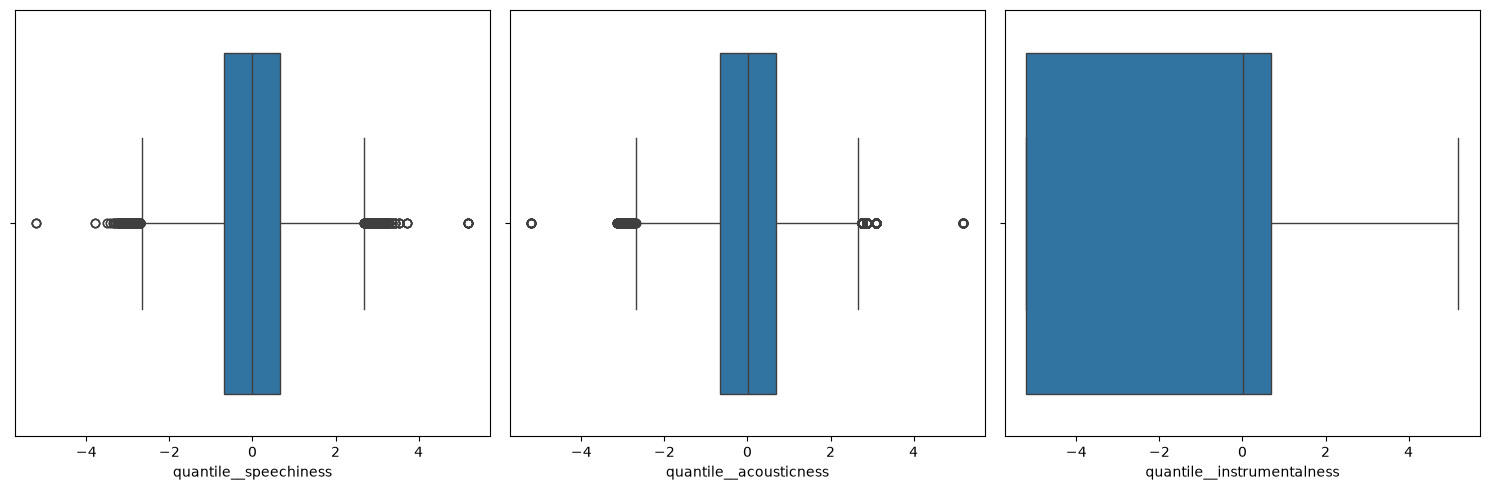

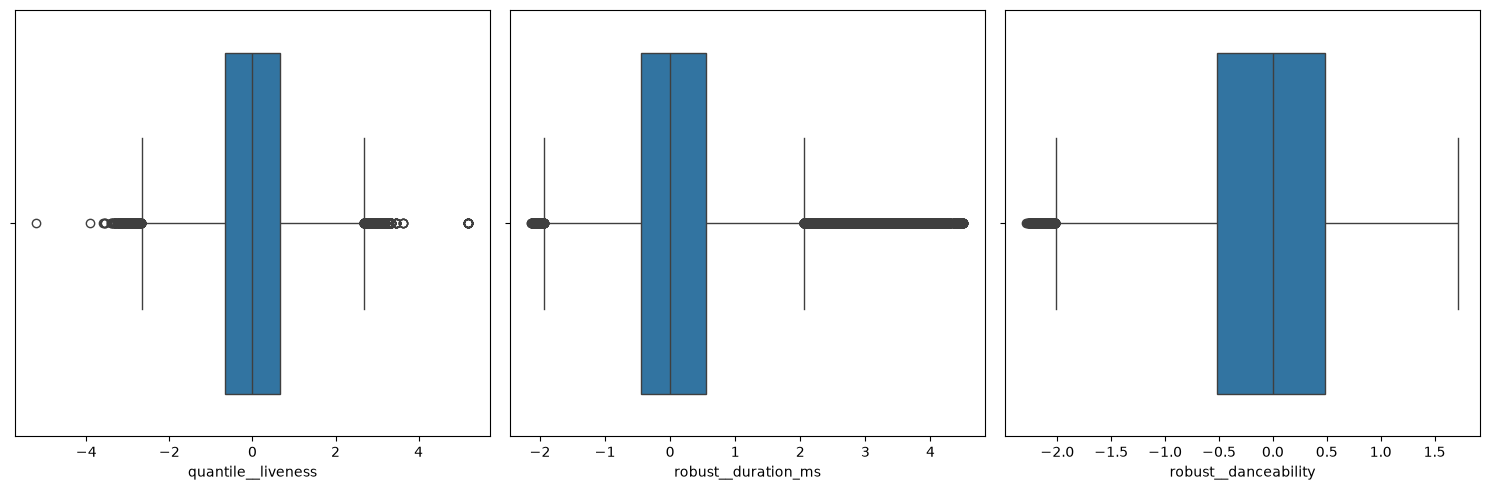

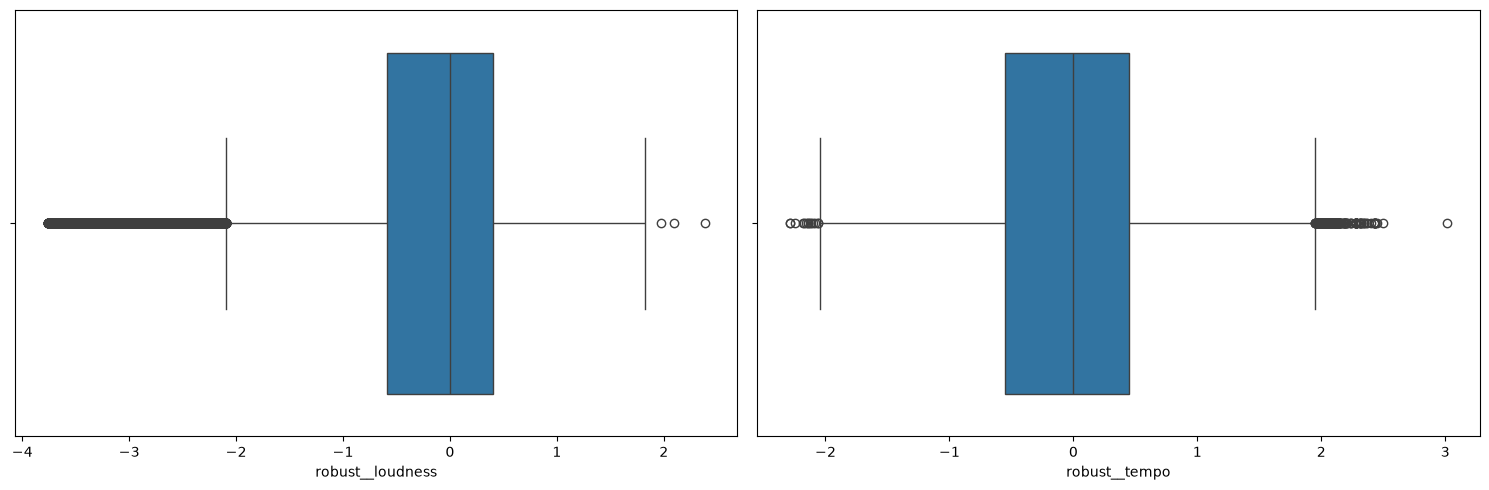

In [106]:
excl = ['remainder__explicit', 'remainder__key', 'remainder__mode', 'remainder__time_signature', 'remainder__track_genre']
numeric_columns = [k for k in df_transformed.columns if k not in excl]
i = 0

while i < len(numeric_columns):
    tmp = len(numeric_columns) - i
    tmp = min(tmp, 3)
    fig, axes = plt.subplots(1, tmp, figsize=(15, 5))
    for j in range(tmp):
        sns.boxplot(data=df, x=df_transformed[numeric_columns[i + j]], ax=axes[j])
    i = i + tmp

    plt.tight_layout()
    plt.show()

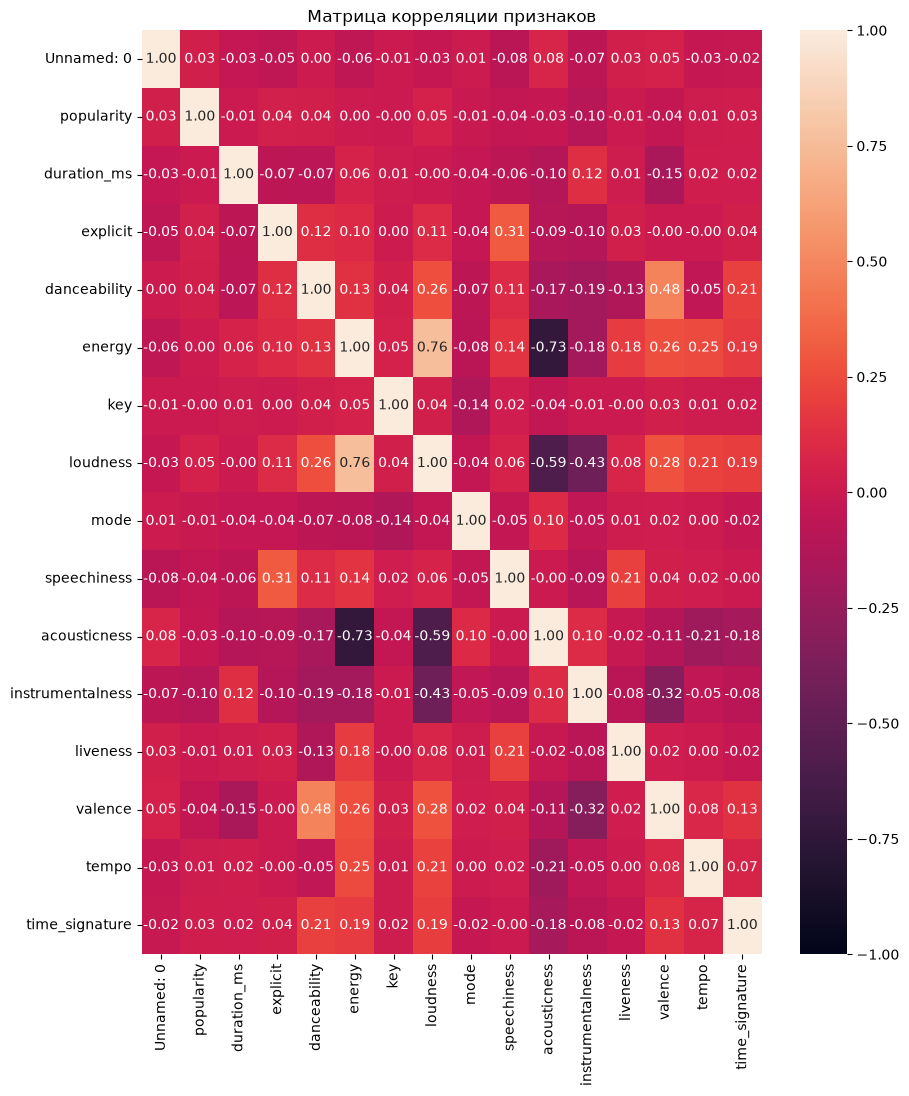

In [ ]:
# Матрица корреляций после нелинейных преобразований
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 12))
sns.heatmap(corr_matrix, annot=True, vmin=-1, vmax=1, fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

Сильный корреляционных зависимостей нету

Для начала напишу KNN только на числовых и категориальных признаках, эмбединги слов сделаю позже и сравню полученные результаты.\
Отложить для прогноза: track_id, artists, album_name, track_name \
Отложить для эмбединга: artists  \
Закодировать: explicit, key, mode, time_signature, track_genre 